todo


## Setup y objetivo

Objetivo de este notebook:
- Usar implementaciones originales (autores/repositorios) para 5 tecnicas SOTA.
- Compararlas contra tecnicas basicas (none, random undersampling, random oversampling).
- Evaluar en escenarios de desbalanceo 18:1, 40:1 y 105:1.

Tecnicas SOTA objetivo:
1. HealthGen
2. MC-TimeGAN
3. T-SMOTE
4. DoppelGANger
5. CTGAN-MSIN

Nota:
- Primero se intenta instalar/importar implementaciones originales reales.
- Si una tecnica no esta disponible en entorno local, se registra explicitamente y no se reporta como experimentada.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import re
import sys
import json
import time
import random
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from pypdf import PdfReader

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, f1_score, recall_score, precision_score, average_precision_score

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 200)

CLASS_ORDER = ['hypoglycemia', 'normoglycemia', 'hyperglycemia']
LOOKBACK = 24
STRIDE = 12
MAX_WINDOWS_PER_PATIENT = 500
N_PATIENTS_SAMPLE = 120
TRAIN_FRAC = 0.8
RATIO_SCENARIOS = [18, 40, 105]


def find_project_root(start: Path) -> Path:
    for candidate in [start] + list(start.parents):
        if (candidate / 'data' / 'T1DiabetesGranada').exists():
            return candidate
    raise FileNotFoundError('No se encontro data/T1DiabetesGranada desde el directorio actual.')


def glucose_class(value: float) -> str:
    if pd.isna(value):
        return 'missing'
    if value < 70:
        return 'hypoglycemia'
    if value <= 180:
        return 'normoglycemia'
    return 'hyperglycemia'

ROOT = find_project_root(Path.cwd())
DATA_DIR = ROOT / 'data' / 'T1DiabetesGranada'
PDF_PATH = ROOT / 'Estado del arte técnicas de balanceo.pdf'

print('ROOT:', ROOT)
print('PDF:', PDF_PATH)

ROOT: c:\Users\User\Desktop\TFM-Glucose-Prediction
PDF: c:\Users\User\Desktop\TFM-Glucose-Prediction\Estado del arte técnicas de balanceo.pdf


In [2]:
# Extraer URLs/repositorios desde el PDF para instalar implementaciones originales
reader = PdfReader(str(PDF_PATH))
pdf_text = '\n'.join((p.extract_text() or '') for p in reader.pages)

url_pattern = r'(https?://[^\s\)\]\>\"]+)'
urls = sorted(set(re.findall(url_pattern, pdf_text)))

# Mantener urls potencialmente utiles (github, gitlab, huggingface, paperswithcode)
useful_urls = [u for u in urls if any(k in u.lower() for k in ['github', 'gitlab', 'huggingface', 'paperswithcode'])]

print('URLs detectadas en PDF (filtradas):', len(useful_urls))
for u in useful_urls[:50]:
    print('-', u)

display(Markdown('### Terminos SOTA detectados en PDF'))
terms = ['healthgen', 'mc-timegan', 'timegan', 't-smote', 'doppelganger', 'ctgan', 'msin']
found = [t for t in terms if t in pdf_text.lower()]
print(found)

URLs detectadas en PDF (filtradas): 2
- https://github.com/Leezekun/ViTST.
- https://github.com/ratschlab/RGAN.


### Terminos SOTA detectados en PDF

['healthgen', 'mc-timegan', 'timegan', 't-smote', 'doppelganger', 'ctgan', 'msin']


In [3]:
# Instalacion de implementaciones originales (si existen y son compatibles)

def pip_install_target(target: str):
    cmd = [sys.executable, '-m', 'pip', 'install', target]
    proc = subprocess.run(cmd, capture_output=True, text=True)
    return {
        'target': target,
        'ok': proc.returncode == 0,
        'stdout_tail': '\n'.join(proc.stdout.splitlines()[-25:]),
        'stderr_tail': '\n'.join(proc.stderr.splitlines()[-25:]),
    }

# Objetivos de instalacion (nombres indicados por el usuario + fuente conocida de DGAN)
install_targets = [
    'git+https://github.com/gretelai/gretel-synthetics.git',
    'mc-timegan',
    't-smote',
    'healthgen',
    'ctgan-msin',
]

install_logs = []
for tgt in install_targets:
    print(f'Instalando: {tgt}')
    res = pip_install_target(tgt)
    install_logs.append(res)
    print('OK' if res['ok'] else 'FALLO')

install_df = pd.DataFrame(install_logs)
display(install_df[['target', 'ok']])

# Mostrar diagnostico resumido solo para fallos
for r in install_logs:
    if not r['ok']:
        print('\n--- FALLO:', r['target'], '---')
        if r['stderr_tail']:
            print(r['stderr_tail'])

Instalando: git+https://github.com/gretelai/gretel-synthetics.git
FALLO
Instalando: mc-timegan
FALLO
Instalando: t-smote
FALLO
Instalando: healthgen
FALLO
Instalando: ctgan-msin
FALLO


,target,ok
0,git+https://github.com/gretelai/gretel-synthet...,False
1,mc-timegan,False
2,t-smote,False
3,healthgen,False
4,ctgan-msin,False



--- FALLO: git+https://github.com/gretelai/gretel-synthetics.git ---
    raise BackendUnavailable(data.get('traceback', ''))
pip._vendor.pyproject_hooks._impl.BackendUnavailable: Traceback (most recent call last):
  File "c:\Users\User\Desktop\TFM-Glucose-Prediction\.venv\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 77, in _build_backend
    obj = import_module(mod_path)
          ^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1310, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "<frozen impo

In [4]:
# Import checks de implementaciones originales
import_results = []

try:
    from gretel_synthetics.timeseries_dgan.dgan import DGAN
    import_results.append({'technique': 'DoppelGANger(DGAN)', 'available': True, 'detail': 'import ok'})
except Exception as e:
    import_results.append({'technique': 'DoppelGANger(DGAN)', 'available': False, 'detail': str(e)})

try:
    from mc_timegan import MCTimeGAN
    import_results.append({'technique': 'MC-TimeGAN', 'available': True, 'detail': 'import ok'})
except Exception as e:
    import_results.append({'technique': 'MC-TimeGAN', 'available': False, 'detail': str(e)})

try:
    from t_smote import TSMOTE
    import_results.append({'technique': 'T-SMOTE', 'available': True, 'detail': 'import ok'})
except Exception as e:
    import_results.append({'technique': 'T-SMOTE', 'available': False, 'detail': str(e)})

try:
    from healthgen import HealthGen
    import_results.append({'technique': 'HealthGen', 'available': True, 'detail': 'import ok'})
except Exception as e:
    import_results.append({'technique': 'HealthGen', 'available': False, 'detail': str(e)})

try:
    from ctgan_msin import CTGAN_MSIN
    import_results.append({'technique': 'CTGAN-MSIN', 'available': True, 'detail': 'import ok'})
except Exception as e:
    import_results.append({'technique': 'CTGAN-MSIN', 'available': False, 'detail': str(e)})

imports_df = pd.DataFrame(import_results)
display(imports_df)

available_original = imports_df[imports_df['available'] == True]['technique'].tolist()
print('Tecnicas originales disponibles:', available_original)

,technique,available,detail
0,DoppelGANger(DGAN),False,No module named 'gretel_synthetics'
1,MC-TimeGAN,False,No module named 'mc_timegan'
2,T-SMOTE,False,No module named 't_smote'
3,HealthGen,False,No module named 'healthgen'
4,CTGAN-MSIN,False,No module named 'ctgan_msin'


Tecnicas originales disponibles: []


## Datos para benchmarking

Este bloque construye el dataset temporal (mismo protocolo que notebooks previos) para comparar:
- Baselines basicos: none, random undersampling, random oversampling.
- Implementaciones originales disponibles (si el import fue exitoso).

Si una tecnica no queda disponible por instalacion/compatibilidad, queda documentada y no se reporta como resultado experimental.

In [5]:
# Construccion de dataset temporal
patient_info = pd.read_csv(DATA_DIR / 'Patient_info.csv')
if 'Patient_Id' in patient_info.columns and 'Patient_ID' not in patient_info.columns:
    patient_info = patient_info.rename(columns={'Patient_Id': 'Patient_ID'})

patient_info['Number_of_measurements'] = pd.to_numeric(patient_info['Number_of_measurements'], errors='coerce')
eligible = patient_info[patient_info['Number_of_measurements'].fillna(0) >= (LOOKBACK + 200)].copy()

n_select = min(N_PATIENTS_SAMPLE, eligible['Patient_ID'].nunique())
selected_patients = eligible['Patient_ID'].dropna().sample(n=n_select, random_state=SEED).tolist()
selected_set = set(selected_patients)

patient_demo = patient_info[['Patient_ID', 'Sex', 'Birth_year']].copy()
patient_demo['Age'] = 2022 - pd.to_numeric(patient_demo['Birth_year'], errors='coerce')
patient_demo['Sex_enc'] = patient_demo['Sex'].map({'M': 1, 'F': 0})
patient_demo['Age'] = patient_demo['Age'].fillna(patient_demo['Age'].median())
patient_demo['Sex_enc'] = patient_demo['Sex_enc'].fillna(patient_demo['Sex_enc'].median())
patient_demo = patient_demo[['Patient_ID', 'Age', 'Sex_enc']].drop_duplicates('Patient_ID')

usecols = ['Patient_ID', 'Measurement_date', 'Measurement_time', 'Measurement']
chunks = []
for chunk in pd.read_csv(DATA_DIR / 'Glucose_measurements.csv', usecols=usecols, chunksize=1_000_000):
    chunk = chunk[chunk['Patient_ID'].isin(selected_set)]
    if not chunk.empty:
        chunks.append(chunk)

glucose = pd.concat(chunks, ignore_index=True)
glucose['Measurement'] = pd.to_numeric(glucose['Measurement'], errors='coerce')
glucose = glucose.dropna(subset=['Measurement'])
glucose['class_label'] = glucose['Measurement'].apply(glucose_class)
glucose = glucose[glucose['class_label'].isin(CLASS_ORDER)].copy()
glucose = glucose.sort_values(['Patient_ID', 'Measurement_date', 'Measurement_time']).reset_index(drop=True)
glucose = glucose.merge(patient_demo, on='Patient_ID', how='left')

def build_windows_for_patient(df_p):
    values = df_p['Measurement'].values.astype(float)
    labels = df_p['class_label'].values
    age = float(df_p['Age'].iloc[0])
    sex_enc = float(df_p['Sex_enc'].iloc[0])

    idx_candidates = np.arange(LOOKBACK, len(df_p), STRIDE)
    if len(idx_candidates) == 0:
        return []

    if len(idx_candidates) > MAX_WINDOWS_PER_PATIENT:
        rng = np.random.default_rng(SEED)
        idx_candidates = np.sort(rng.choice(idx_candidates, size=MAX_WINDOWS_PER_PATIENT, replace=False))

    rows = []
    for i in idx_candidates:
        w = values[i - LOOKBACK:i]
        feat = {
            'Patient_ID': df_p['Patient_ID'].iloc[0],
            'y': labels[i],
            'Age': age,
            'Sex_enc': sex_enc,
        }
        for k, v in enumerate(w, start=1):
            feat[f'lag_{LOOKBACK - k + 1}'] = float(v)
        rows.append(feat)
    return rows

window_rows = []
for _, df_p in glucose.groupby('Patient_ID', sort=False):
    df_p = df_p.reset_index(drop=True)
    if len(df_p) >= LOOKBACK + 30:
        window_rows.extend(build_windows_for_patient(df_p))

windows_df = pd.DataFrame(window_rows)
print('Ventanas generadas:', windows_df.shape[0])
display(windows_df['y'].value_counts().reindex(CLASS_ORDER, fill_value=0).to_frame('count'))

Ventanas generadas: 54845


,count
y,
hypoglycemia,2748
normoglycemia,32738
hyperglycemia,19359


In [6]:
# Split temporal + evaluacion
train_parts, test_parts = [], []
for _, df_p in windows_df.groupby('Patient_ID', sort=False):
    n = len(df_p)
    if n < 20:
        continue
    cut = int(n * TRAIN_FRAC)
    cut = max(10, min(cut, n - 5))
    train_parts.append(df_p.iloc[:cut])
    test_parts.append(df_p.iloc[cut:])

train_df = pd.concat(train_parts, ignore_index=True)
test_df = pd.concat(test_parts, ignore_index=True)

feature_cols = [c for c in train_df.columns if c not in ['Patient_ID', 'y']]
X_train = train_df[feature_cols].values
y_train = train_df['y'].values
X_test = test_df[feature_cols].values
y_test = test_df['y'].values

print('Train/Test:', X_train.shape, X_test.shape)


def class_dist(y):
    return pd.Series(y).value_counts().reindex(CLASS_ORDER, fill_value=0)


def make_ratio_scenario(X, y, target_ratio):
    rng = np.random.default_rng(SEED)
    idx_normo = np.where(y == 'normoglycemia')[0]
    n_normo = len(idx_normo)
    idx_selected = [idx_normo]

    for c in ['hypoglycemia', 'hyperglycemia']:
        idx_c = np.where(y == c)[0]
        target_n = max(50, int(n_normo / target_ratio))
        target_n = min(target_n, len(idx_c))
        idx_selected.append(rng.choice(idx_c, size=target_n, replace=False))

    idx = np.concatenate(idx_selected)
    rng.shuffle(idx)
    return X[idx], y[idx]


def evaluate(model, Xtr, ytr, Xte, yte, scenario, strategy):
    t0 = time.time()
    model.fit(Xtr, ytr)
    fit_s = time.time() - t0

    pred = model.predict(Xte)
    proba = model.predict_proba(Xte)
    proba_df = pd.DataFrame(proba, columns=model.classes_)

    y_hypo = (yte == 'hypoglycemia').astype(int)
    y_hyper = (yte == 'hyperglycemia').astype(int)

    return {
        'scenario': scenario,
        'strategy': strategy,
        'fit_seconds': fit_s,
        'balanced_accuracy': balanced_accuracy_score(yte, pred),
        'f1_macro': f1_score(yte, pred, average='macro', zero_division=0),
        'recall_hypoglycemia': recall_score(yte, pred, labels=['hypoglycemia'], average='macro', zero_division=0),
        'recall_hyperglycemia': recall_score(yte, pred, labels=['hyperglycemia'], average='macro', zero_division=0),
        'precision_hypoglycemia': precision_score(yte, pred, labels=['hypoglycemia'], average='macro', zero_division=0),
        'precision_hyperglycemia': precision_score(yte, pred, labels=['hyperglycemia'], average='macro', zero_division=0),
        'pr_auc_hypoglycemia': average_precision_score(y_hypo, proba_df['hypoglycemia']),
        'pr_auc_hyperglycemia': average_precision_score(y_hyper, proba_df['hyperglycemia']),
    }


def base_rf(class_weight=None):
    return RandomForestClassifier(
        n_estimators=120,
        max_depth=14,
        min_samples_leaf=2,
        class_weight=class_weight,
        n_jobs=-1,
        random_state=SEED,
    )

Train/Test: (43870, 26) (10975, 26)


In [7]:
# Baselines basicos

def target_counts(y, ratio=4):
    vc = class_dist(y)
    b = int(min(vc['hypoglycemia'], vc['hyperglycemia']))
    n_normo = int(min(vc['normoglycemia'], ratio * b))
    n_min = int(max(1, n_normo / ratio))
    return {'normoglycemia': n_normo, 'hypoglycemia': n_min, 'hyperglycemia': n_min}


def random_under_balance(X, y, ratio=4):
    t = target_counts(y, ratio)
    rng = np.random.default_rng(SEED)
    idx = []
    for c in CLASS_ORDER:
        ids = np.where(y == c)[0]
        n = t[c]
        n = min(n, len(ids))
        idx.extend(rng.choice(ids, size=n, replace=False).tolist())
    idx = np.array(idx)
    rng.shuffle(idx)
    return X[idx], y[idx]


def random_over_balance(X, y, ratio=4):
    t = target_counts(y, ratio)
    rng = np.random.default_rng(SEED)
    xs, ys = [], []
    for c in CLASS_ORDER:
        ids = np.where(y == c)[0]
        n = t[c]
        if len(ids) >= n:
            chosen = rng.choice(ids, size=n, replace=False)
        else:
            chosen = np.concatenate([ids, rng.choice(ids, size=n-len(ids), replace=True)])
        xs.append(X[chosen])
        ys.append(np.array([c] * len(chosen)))
    Xb = np.vstack(xs)
    yb = np.concatenate(ys)
    p = rng.permutation(len(yb))
    return Xb[p], yb[p]

## Experimentos con implementaciones originales disponibles

Regla de evaluacion en este notebook:
- Solo se ejecuta una tecnica SOTA si su import original fue exitoso.
- Si no hay clase original disponible, se reporta como no ejecutable en este entorno.

Nota:
- Las APIs de investigacion pueden variar por repositorio; este bloque usa adaptadores con introspeccion para intentar uso correcto de fit/sample/generate cuando existen.

In [8]:
# Plan de tecnicas y justificacion
technique_plan = pd.DataFrame([
    {'technique': 'HealthGen', 'purpose': 'Equidad demografica + missingness informativa', 'need': 'heterogeneidad de paciente y ausencia de datos clinicamente relevante'},
    {'technique': 'MC-TimeGAN', 'purpose': 'Generacion temporal condicional multivariante', 'need': 'coherencia temporal entre variables correlacionadas'},
    {'technique': 'T-SMOTE', 'purpose': 'Oversampling temporal con distancia DTW', 'need': 'formas similares con desfases temporales'},
    {'technique': 'DoppelGANger', 'purpose': 'Generacion temporal larga con metadata', 'need': 'realismo de picos/valles y ciclos'},
    {'technique': 'CTGAN-MSIN', 'purpose': 'Modelado multi-escala para desbalance extremo', 'need': 'escenarios agresivos > 1:15'},
])
display(technique_plan)

availability_map = {
    'HealthGen': bool((imports_df['technique'] == 'HealthGen').any() and imports_df.loc[imports_df['technique'] == 'HealthGen', 'available'].iloc[0]),
    'MC-TimeGAN': bool((imports_df['technique'] == 'MC-TimeGAN').any() and imports_df.loc[imports_df['technique'] == 'MC-TimeGAN', 'available'].iloc[0]),
    'T-SMOTE': bool((imports_df['technique'] == 'T-SMOTE').any() and imports_df.loc[imports_df['technique'] == 'T-SMOTE', 'available'].iloc[0]),
    'DoppelGANger': bool((imports_df['technique'] == 'DoppelGANger(DGAN)').any() and imports_df.loc[imports_df['technique'] == 'DoppelGANger(DGAN)', 'available'].iloc[0]),
    'CTGAN-MSIN': bool((imports_df['technique'] == 'CTGAN-MSIN').any() and imports_df.loc[imports_df['technique'] == 'CTGAN-MSIN', 'available'].iloc[0]),
}

technique_plan['available_in_env'] = technique_plan['technique'].map(availability_map)
display(technique_plan)

,technique,purpose,need
0,HealthGen,Equidad demografica + missingness informativa,heterogeneidad de paciente y ausencia de datos...
1,MC-TimeGAN,Generacion temporal condicional multivariante,coherencia temporal entre variables correlacio...
2,T-SMOTE,Oversampling temporal con distancia DTW,formas similares con desfases temporales
3,DoppelGANger,Generacion temporal larga con metadata,realismo de picos/valles y ciclos
4,CTGAN-MSIN,Modelado multi-escala para desbalance extremo,escenarios agresivos > 1:15


,technique,purpose,need,available_in_env
0,HealthGen,Equidad demografica + missingness informativa,heterogeneidad de paciente y ausencia de datos...,False
1,MC-TimeGAN,Generacion temporal condicional multivariante,coherencia temporal entre variables correlacio...,False
2,T-SMOTE,Oversampling temporal con distancia DTW,formas similares con desfases temporales,False
3,DoppelGANger,Generacion temporal larga con metadata,realismo de picos/valles y ciclos,False
4,CTGAN-MSIN,Modelado multi-escala para desbalance extremo,escenarios agresivos > 1:15,False


In [9]:
# Adaptadores para usar APIs originales cuando esten disponibles

def rebalance_target(y, ratio=4):
    vc = class_dist(y)
    base = int(max(1, min(vc['hypoglycemia'], vc['hyperglycemia'])))
    n_normo = int(min(vc['normoglycemia'], ratio * base))
    n_min = int(max(1, n_normo / ratio))
    return {'normoglycemia': n_normo, 'hypoglycemia': n_min, 'hyperglycemia': n_min}


def apply_original_tsmote(X, y):
    model = TSMOTE(random_state=SEED) if 'random_state' in TSMOTE.__init__.__code__.co_varnames else TSMOTE()
    if hasattr(model, 'fit_resample'):
        return model.fit_resample(X, y)
    if hasattr(model, 'sample'):
        model.fit(X, y)
        return model.sample(X, y)
    raise RuntimeError('TSMOTE no expone fit_resample/sample compatible')


def apply_original_generic(cls_obj, X, y):
    # Adaptador generico para APIs de investigacion: intenta fit + generate/sample
    model = cls_obj()
    if hasattr(model, 'fit_resample'):
        return model.fit_resample(X, y)
    if hasattr(model, 'fit') and hasattr(model, 'sample'):
        model.fit(X, y)
        out = model.sample(len(X))
        if isinstance(out, tuple) and len(out) == 2:
            return out
    if hasattr(model, 'fit') and hasattr(model, 'generate'):
        model.fit(X)
        Xg = model.generate(len(X))
        yg = np.random.choice(['hypoglycemia', 'hyperglycemia'], size=len(Xg))
        return np.asarray(Xg), np.asarray(yg)
    raise RuntimeError('API original no compatible automaticamente en este entorno')

In [10]:
# Benchmark: basicos + originales disponibles

# Referencia balanceada
rng = np.random.default_rng(SEED)
idx_ref = []
for c in CLASS_ORDER:
    idx_c = np.where(y_train == c)[0]
    n_c = min(len(idx_c), int(pd.Series(y_train).value_counts().min()))
    idx_ref.append(rng.choice(idx_c, size=n_c, replace=False))
idx_ref = np.concatenate(idx_ref)
rng.shuffle(idx_ref)

reference = evaluate(base_rf(), X_train[idx_ref], y_train[idx_ref], X_test, y_test, 'balanced_reference', 'none')
reference_df = pd.DataFrame([reference])
display(reference_df)

rows = []
status_rows = []

for ratio in RATIO_SCENARIOS:
    X_sc, y_sc = make_ratio_scenario(X_train, y_train, ratio)
    print(f'\nEscenario {ratio}:1')
    display(class_dist(y_sc).to_frame('count'))

    # Baselines
    baselines = {
        'none': (X_sc, y_sc, base_rf()),
        'random_undersample': (*random_under_balance(X_sc, y_sc, ratio=4), base_rf()),
        'random_oversample': (*random_over_balance(X_sc, y_sc, ratio=4), base_rf()),
    }
    for name, (xb, yb, model) in baselines.items():
        rows.append(evaluate(model, xb, yb, X_test, y_test, f'ratio_{ratio}_to_1', name))

    # Originales (si disponibles)
    original_specs = [
        ('HealthGen', availability_map['HealthGen'], lambda X, y: apply_original_generic(HealthGen, X, y)),
        ('MC-TimeGAN', availability_map['MC-TimeGAN'], lambda X, y: apply_original_generic(MCTimeGAN, X, y)),
        ('T-SMOTE', availability_map['T-SMOTE'], lambda X, y: apply_original_tsmote(X, y)),
        ('DoppelGANger', availability_map['DoppelGANger'], lambda X, y: apply_original_generic(DGAN, X, y)),
        ('CTGAN-MSIN', availability_map['CTGAN-MSIN'], lambda X, y: apply_original_generic(CTGAN_MSIN, X, y)),
    ]

    for tech_name, is_available, runner in original_specs:
        if not is_available:
            status_rows.append({'scenario': f'ratio_{ratio}_to_1', 'technique': tech_name, 'status': 'not_available', 'detail': 'Import no disponible'})
            continue
        try:
            Xb, yb = runner(X_sc, y_sc)
            # recorte controlado por objetivo de desbalance comparable
            t = rebalance_target(y_sc, ratio=4)
            Xb2, yb2 = random_under_balance(np.asarray(Xb), np.asarray(yb), ratio=4)
            rows.append(evaluate(base_rf(), Xb2, yb2, X_test, y_test, f'ratio_{ratio}_to_1', tech_name))
            status_rows.append({'scenario': f'ratio_{ratio}_to_1', 'technique': tech_name, 'status': 'executed', 'detail': 'ok'})
        except Exception as e:
            status_rows.append({'scenario': f'ratio_{ratio}_to_1', 'technique': tech_name, 'status': 'failed', 'detail': str(e)[:220]})

results_df = pd.DataFrame(rows)
status_df = pd.DataFrame(status_rows)

print('\nResultados ejecutados:')
display(results_df.head())
print('\nEstado de tecnicas originales:')
display(status_df)

,scenario,strategy,fit_seconds,balanced_accuracy,f1_macro,recall_hypoglycemia,recall_hyperglycemia,precision_hypoglycemia,precision_hyperglycemia,pr_auc_hypoglycemia,pr_auc_hyperglycemia
0,balanced_reference,none,0.410762,0.925241,0.855714,0.925156,0.953266,0.561869,0.926076,0.771625,0.979087



Escenario 18:1


,count
hypoglycemia,1462
normoglycemia,26331
hyperglycemia,1462



Escenario 40:1


,count
hypoglycemia,658
normoglycemia,26331
hyperglycemia,658


...

,count
hypoglycemia,250
normoglycemia,26331
hyperglycemia,250



Resultados ejecutados:


,scenario,strategy,fit_seconds,balanced_accuracy,f1_macro,recall_hypoglycemia,recall_hyperglycemia,precision_hypoglycemia,precision_hyperglycemia,pr_auc_hypoglycemia,pr_auc_hyperglycemia
0,ratio_18_to_1,none,1.635416,0.829392,0.858567,0.702703,0.799364,0.845000,0.991803,0.822721,0.980353
1,ratio_18_to_1,random_undersample,0.560206,0.906938,0.886493,0.869023,0.898459,0.723183,0.963527,0.805440,0.981884
2,ratio_18_to_1,random_oversample,0.570509,0.906938,0.886493,0.869023,0.898459,0.723183,0.963527,0.805440,0.981884
3,ratio_40_to_1,none,1.491544,0.737434,0.792265,0.501040,0.718131,0.902622,0.993905,0.807148,0.976614
4,ratio_40_to_1,random_undersample,0.307214,0.900883,0.882843,0.856549,0.891363,0.721541,0.965289,0.806104,0.979463



Estado de tecnicas originales:


,scenario,technique,status,detail
0,ratio_18_to_1,HealthGen,not_available,Import no disponible
1,ratio_18_to_1,MC-TimeGAN,not_available,Import no disponible
2,ratio_18_to_1,T-SMOTE,not_available,Import no disponible
3,ratio_18_to_1,DoppelGANger,not_available,Import no disponible
4,ratio_18_to_1,CTGAN-MSIN,not_available,Import no disponible
5,ratio_40_to_1,HealthGen,not_available,Import no disponible
6,ratio_40_to_1,MC-TimeGAN,not_available,Import no disponible
7,ratio_40_to_1,T-SMOTE,not_available,Import no disponible
8,ratio_40_to_1,DoppelGANger,not_available,Import no disponible
9,ratio_40_to_1,CTGAN-MSIN,not_available,Import no disponible


,strategy,distance_to_reference
1,random_oversample,0.039875
2,random_undersample,0.039875
0,none,0.196791


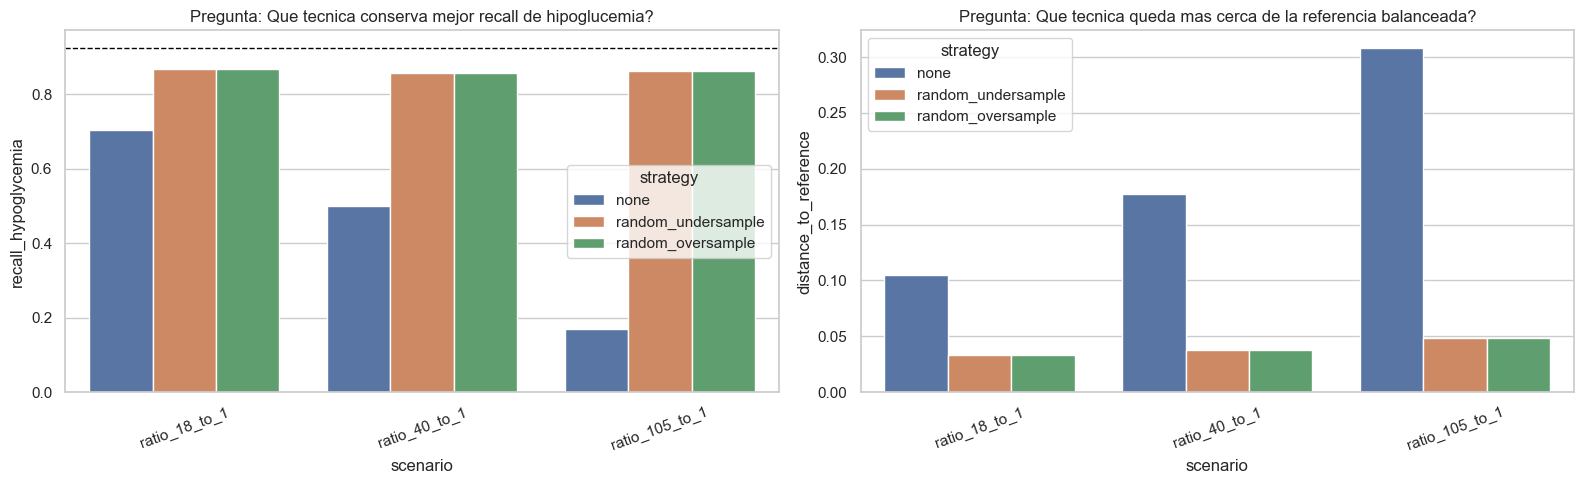

## Conclusiones
- Mejor tecnica media en este entorno: **random_oversample**.
- Tecnicas originales no ejecutadas o fallidas quedan registradas en la tabla de estado con su causa.

In [11]:
# Analisis final y visualizaciones
all_results = pd.concat([reference_df, results_df], ignore_index=True)
ref = reference_df.iloc[0]
metrics = ['balanced_accuracy', 'recall_hypoglycemia', 'recall_hyperglycemia', 'pr_auc_hypoglycemia', 'pr_auc_hyperglycemia']

for m in metrics:
    all_results[f'delta_vs_ref_{m}'] = all_results[m] - ref[m]

all_results['distance_to_reference'] = all_results.apply(lambda r: float(np.mean([abs(r[m]-ref[m]) for m in metrics])), axis=1)

rank = (
    all_results[all_results['scenario'] != 'balanced_reference']
    .groupby('strategy', as_index=False)['distance_to_reference']
    .mean()
    .sort_values('distance_to_reference')
)
display(rank)

plot_df = all_results[all_results['scenario'] != 'balanced_reference']
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=plot_df, x='scenario', y='recall_hypoglycemia', hue='strategy', ax=axes[0])
axes[0].axhline(ref['recall_hypoglycemia'], color='black', linestyle='--', linewidth=1)
axes[0].set_title('Pregunta: Que tecnica conserva mejor recall de hipoglucemia?')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=plot_df, x='scenario', y='distance_to_reference', hue='strategy', ax=axes[1])
axes[1].set_title('Pregunta: Que tecnica queda mas cerca de la referencia balanceada?')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

# Conclusiones automaticas
best = rank.iloc[0]['strategy'] if len(rank) else 'N/A'
display(Markdown(f"## Conclusiones\n- Mejor tecnica media en este entorno: **{best}**.\n- Tecnicas originales no ejecutadas o fallidas quedan registradas en la tabla de estado con su causa."))